#1. Import Libraries

In [1]:
# Core libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

#2. Load Dataset

In [2]:
data_path ="../data/raw/telecom_churn.csv"

# Load raw telecom churn dataset
df = pd.read_csv(data_path)
df.head()

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,is_multi_service,network_issues_3m,dropped_call_rate,avg_data_speed_mbps,num_complaints_3m,num_complaints_12m,call_center_interactions_3m,last_complaint_resolution_days,app_logins_30d,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,92927.66,10.69,453.0,102.0,0.00,1,0,1,0.035772,20.657628,1,1,2,3.3,8,3,0,0,0.4,1133.57,High,13.0,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,19368.90,34.65,797.0,29.0,169.54,0,1,3,0.015473,11.957035,0,0,1,0.0,6,2,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,36123.77,5.22,687.0,73.0,0.74,0,0,1,0.028856,21.120911,1,3,2,5.4,5,3,1,0,0.0,307.05,Low,53.0,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,16476.90,24.49,232.0,0.0,78.21,1,0,0,0.033661,16.733437,0,1,0,0.0,7,5,1,0,0.0,214.89,Low,20.0,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,37683.17,50.46,450.0,35.0,75.60,0,0,5,0.013339,8.692907,0,0,0,0.0,6,4,0,0,0.5,383.99,Low,17.0,2.6,0,0,0


#3. Data Structure and Summary

In [3]:
df.info()

# Cleaning and renaming to match workflow
rename_map = {
    "num_complaints_3m": "complaints_3m",
    "dropped_call_rate": "call_drop_rate"
}

df.rename(columns=rename_map, inplace=True)
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  object 
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  object 
 4   connection_type                 25000 non-null  object 
 5   plan_type                       25000 non-null  object 
 6   contract_type                   25000 non-null  object 
 7   base_plan_category              25000 non-null  object 
 8   tenure_months                   25000 non-null  int64  
 9   monthly_charges                 25000 non-null  float64
 10  total_charges                   25000 non-null  float64
 11  avg_data_gb_month               25000 non-null  float64
 12  avg_voice_mins_month            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25000.0,NaN,NaN,NaN,112499.5,7217.022701,100000.0,106249.75,112499.5,118749.25,124999.0
gender,25000,3,Female,12070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,25000.0,NaN,NaN,NaN,45.9602,16.401422,18.0,32.0,46.0,60.0,74.0
region_circle,25000,5,North,5615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
connection_type,25000,3,4G,12518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_type,25000,2,Prepaid,17522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,25000,4,No Contract,17522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_plan_category,25000,6,Prepaid Regular,8755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,25000.0,NaN,NaN,NaN,60.1496,34.374772,1.0,31.0,60.0,90.0,119.0
monthly_charges,25000.0,NaN,NaN,NaN,475.518315,267.550787,99.0,300.6075,385.735,601.25,1603.49


#4. Churn vs Non-Churn Distribution

Churn counts:


is_churn
0    14643
1    10357
Name: count, dtype: int64


Churn ratio: 41.4280%


Text(0.5, 1.0, 'Class distribution (0 = retained, 1 = churned)')

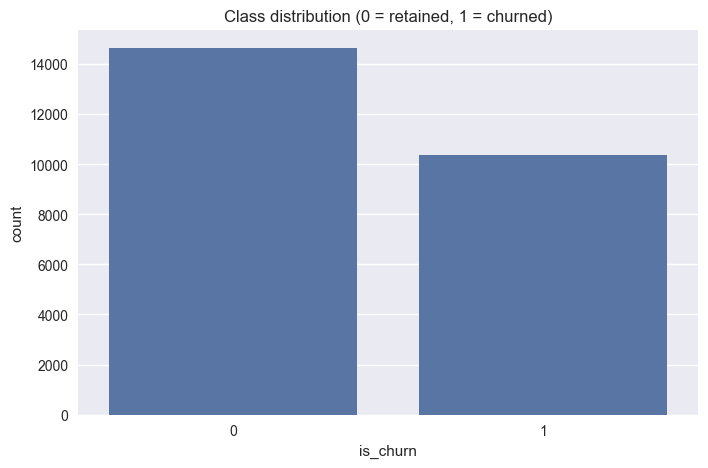

In [4]:
# Churn vs non-churn counts
churn_counts = df["is_churn"].value_counts()
churn_ratio = df["is_churn"].mean()

print("Churn counts:")
display(churn_counts)
print(f"\nChurn ratio: {churn_ratio:.4%}")
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="is_churn", data=df)
plt.title("Class distribution (0 = retained, 1 = churned)")


#5. Monthly Charges Distribution

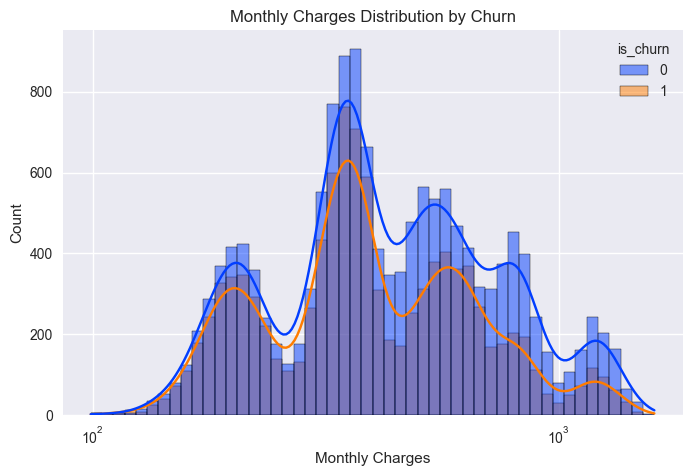

In [5]:
# Visualize overall monthly charges distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="monthly_charges",
    palette="bright",
    hue="is_churn",
    bins=50,
    log_scale=True,
    kde=True
    )
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.show()

#6. Monthly Charges vs Churn Label

In [6]:
# Compare charges distribution using violin plot
df["log_charges"] = np.log1p(df["monthly_charges"])

fig = px.violin(
    df,
    x="is_churn",
    y="log_charges",
    color="is_churn",
    box=True,
    points="all",
)

fig.update_layout(
    title="Log Monthly Charges by Churn Label",
    xaxis_title="Churn Label",
    yaxis_title="log(1 + Monthly Charges)",
)

fig.show()

#7. Service and Quality Patterns

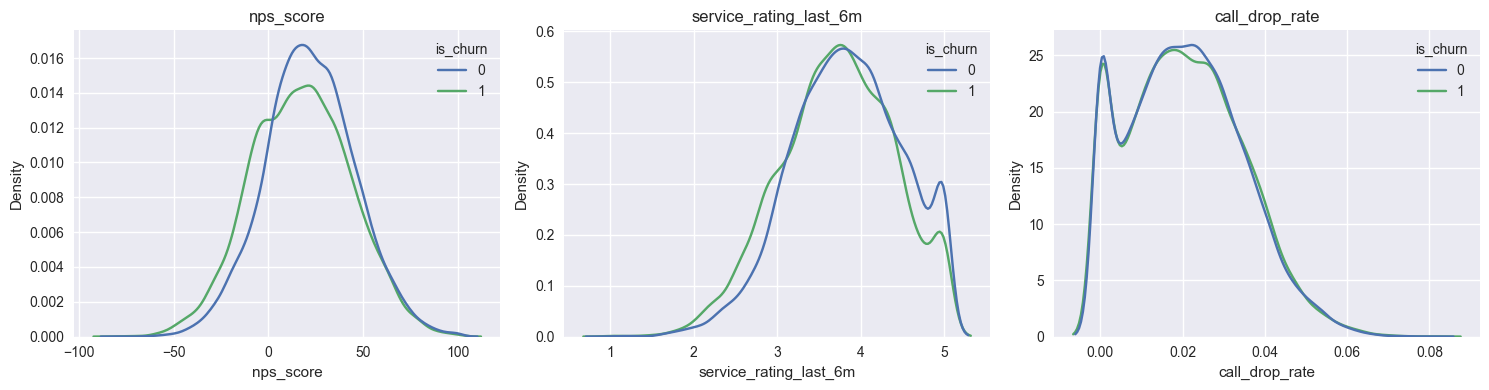

,churn_rate,count
contract_type,,
No Contract,0.457025,17522
Month-to-Month,0.328176,4589
1 Year,0.312063,2147
2 Year,0.233154,742


In [7]:
# Analyze quality score distributions for churn
quality_cols = [
    "nps_score",
    "service_rating_last_6m",
    "call_drop_rate",
]

fig, axes = plt.subplots(1, len(quality_cols), figsize=(5 * len(quality_cols), 4))
for ax, col in zip(axes, quality_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="is_churn",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

def churn_rate_by(col):
    tmp = (
        df.groupby(col)["is_churn"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "churn_rate", "count": "count"})
        .sort_values("churn_rate", ascending=False)
    )
    return tmp

# Analyze key categorical indicators
churn_rate_by("contract_type")

#8. Churn Rate by Plan Type

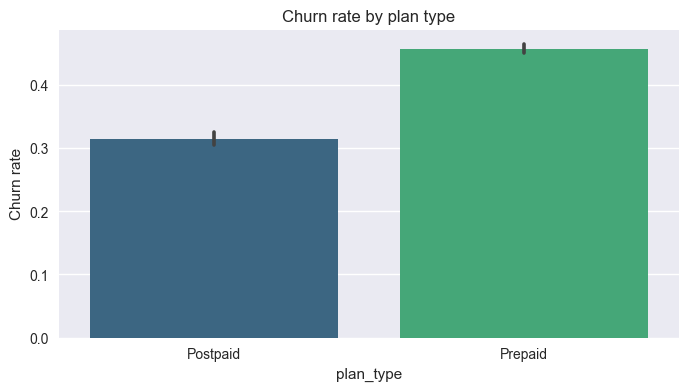

In [8]:
# Calculate churn rate per plan type
plt.figure(figsize=(8, 4))
sns.barplot(
    x="plan_type",
    y="is_churn",
    data=df,
    estimator=np.mean,
    errorbar="ci",
    palette="viridis",
    hue="plan_type",
    legend=False
)
plt.title("Churn rate by plan type")
plt.ylabel("Churn rate")
plt.show()

#9. Correlation Analysis

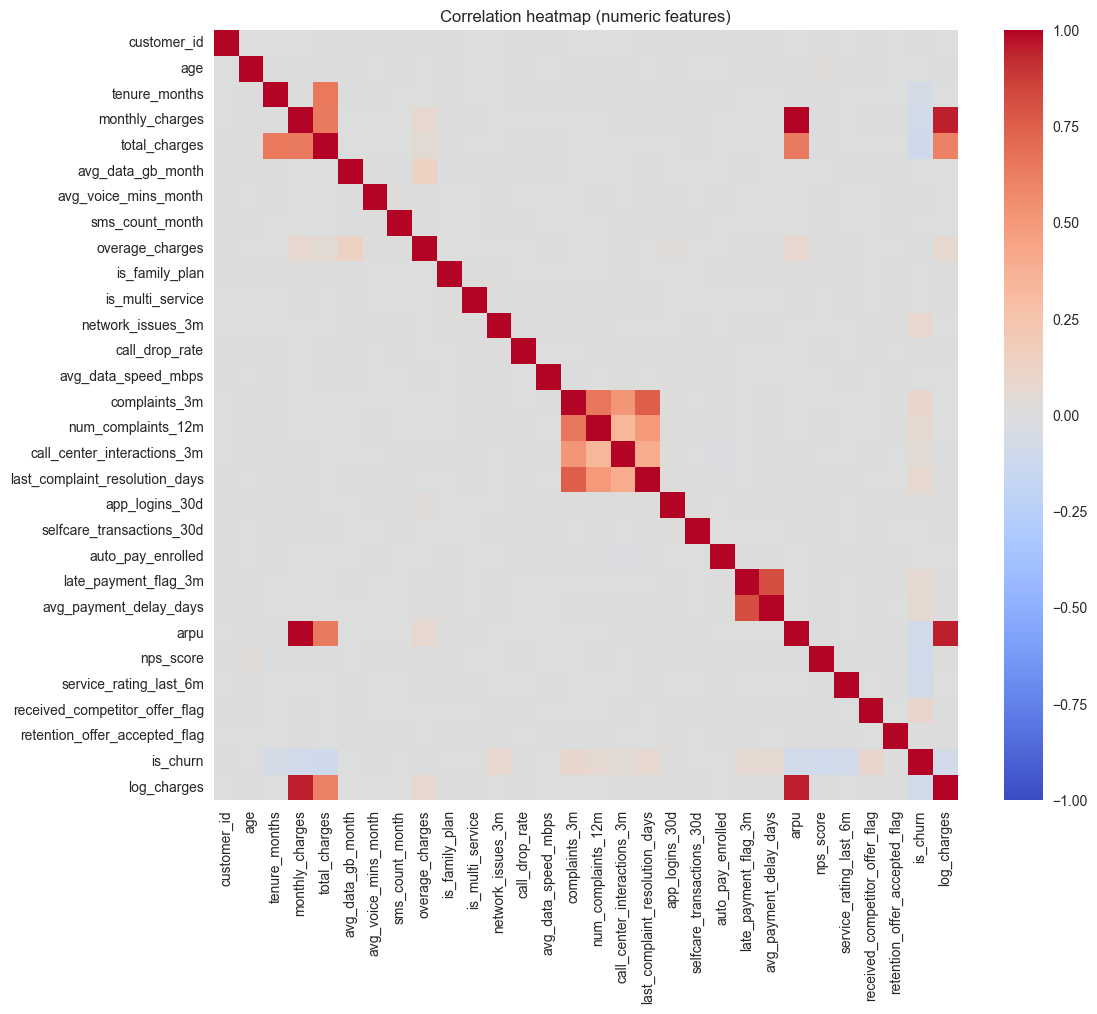

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

# Check relationships between numeric features
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0.0,
    vmax=1.0,
    vmin=-1.0,
    square=False,
)
plt.title("Correlation heatmap (numeric features)")
plt.show()

10. Save Processed Data

In [10]:
import os

# Create directory if it does not exist
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "telecom_clean.csv")

# Save cleaned data for next stages
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path}")

Cleaned data saved to ../data/processed\telecom_clean.csv
